# Trajectory Covariance Spectrum Decay

This notebook analyzes each latent trajectory as a matrix of shape `(L, D)`.

For each trajectory it:
1. extracts the response or reasoning-span latent sequence,
2. computes the token-wise covariance matrix over latent dimensions,
3. computes the covariance eigenspectrum,
4. estimates a **power-law decay exponent** from the slope of `log(eigenvalue)` vs `log(rank)`,
5. plots success vs decay rate in 2D.

Interpretation idea:
- larger power-law exponent means the spectrum decays faster,
- smaller exponent means variance is spread across more directions.


In [1]:
from pathlib import Path
import json
import random

import matplotlib.pyplot as plt
import numpy as np
import torch

from research.buffer import ParquetLatentBuffer
from research.latent.codec import deserialize_latent_tensor

OUTPUT_DIR = Path('/workspace/outputs/offline_math500_temp1_k32/allenai_llama_3_1_tulu_3_8b') # allenai_llama_3_1_tulu_3_8b
USE_REASONING_SPAN = True
RANDOM_SEED = 1
MAX_COMPONENTS = 64
MIN_SEQ_LEN = 4
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)


def load_jsonl(path: Path):
    rows = []
    with path.open(encoding='utf-8') as f:
        for line in f:
            if line.strip():
                rows.append(json.loads(line))
    return rows

metadata_path = OUTPUT_DIR / 'metadata.jsonl'
buffer_dir = OUTPUT_DIR / 'buffer'
summary_path = OUTPUT_DIR / 'collection_summary.json'

assert metadata_path.exists(), f'missing metadata: {metadata_path}'
assert buffer_dir.exists(), f'missing buffer: {buffer_dir}'

metadata_rows = load_jsonl(metadata_path)
metadata_by_uid = {row['uid']: row for row in metadata_rows}
print(f'Loaded {len(metadata_rows)} metadata rows from {metadata_path}')
if summary_path.exists():
    print(summary_path.read_text(encoding='utf-8'))

Loaded 3200 metadata rows from /workspace/outputs/offline_math500_temp1_k32/allenai_llama_3_1_tulu_3_8b/metadata.jsonl
{
  "model": "allenai/Llama-3.1-Tulu-3-8B",
  "input": "/workspace/data/math500_local_allenai_llama_3_1_tulu_3_8b.jsonl",
  "output_dir": "/workspace/outputs/offline_math500_temp1_k32/allenai_llama_3_1_tulu_3_8b",
  "buffer_dir": "/workspace/outputs/offline_math500_temp1_k32/allenai_llama_3_1_tulu_3_8b/buffer",
  "metadata_path": "/workspace/outputs/offline_math500_temp1_k32/allenai_llama_3_1_tulu_3_8b/metadata.jsonl",
  "processed_examples": 100,
  "saved_questions": 100,
  "saved_sequences": 3199,
  "skipped_existing_sequences": 0,
  "num_samples_per_question": 32,
  "temperature": 1.0,
  "seed": 100001,
  "resume": true,
  "layer_index": -1,
  "latent_dtype": "fp16",
  "device": "cuda",
  "buffer_stats": {
    "buffer/total_samples": 3199,
    "buffer/total_shards": 3199,
    "buffer/pending_rows": 0
  }
}



In [ ]:
# Trend uncertainty band mode for binned mean plots.
TREND_ERROR_MODE = 'stderr'  # one of: 'stderr', 'std'
assert TREND_ERROR_MODE in {'stderr', 'std'}
print('TREND_ERROR_MODE =', TREND_ERROR_MODE)


In [2]:
buffer = ParquetLatentBuffer(
    root_dir=str(buffer_dir),
    shard_max_samples=256,
    compression='zstd',
    max_disk_gb=1000.0,
)
rows = list(buffer.iter_rows())
rows = [row for row in rows if row['uid'] in metadata_by_uid]
print(f'Loaded {len(rows)} latent rows from buffer')
print('Buffer stats:', buffer.get_stats())

Loaded 3199 latent rows from buffer
Buffer stats: {'buffer/total_samples': 3199, 'buffer/total_shards': 3199, 'buffer/pending_rows': 0}


In [3]:
def extract_sequence_for_analysis(row, meta, use_reasoning_span=True):
    seq = deserialize_latent_tensor(
        row['latent_blob'],
        seq_len=int(row['response_length']),
        hidden_dim=int(row['hidden_dim']),
        dtype=str(row['dtype']),
    ).float()

    start = 0
    end = seq.shape[0]
    if use_reasoning_span and meta.get('think_token_start') is not None and meta.get('think_token_end') is not None:
        start = int(meta['think_token_start'])
        end = int(meta['think_token_end'])
        start = max(0, min(start, seq.shape[0]))
        end = max(start + 1, min(end, seq.shape[0]))
    return seq[start:end]


def covariance_eigenspectrum(seq):
    x = seq.numpy().astype(np.float64)
    x = x - x.mean(axis=0, keepdims=True)
    if x.shape[0] < 2:
        return None
    cov = (x.T @ x) / max(1, x.shape[0] - 1)
    eigvals = np.linalg.eigvalsh(cov)
    eigvals = np.sort(eigvals)[::-1]
    eigvals = np.clip(eigvals, 1e-12, None)
    return eigvals


def estimate_powerlaw_exponent(eigvals, max_components=256):
    eigvals = np.asarray(eigvals, dtype=np.float64)
    k = min(len(eigvals), max_components)
    if k < 3:
        return None
    ranks = np.arange(1, k + 1, dtype=np.float64)
    x = np.log(ranks)
    y = np.log(eigvals[:k])
    slope, intercept = np.polyfit(x, y, deg=1)
    return float(-slope)

samples = []
for row in rows:
    meta = metadata_by_uid[row['uid']]
    seq = extract_sequence_for_analysis(row, meta, use_reasoning_span=USE_REASONING_SPAN)
    if seq.shape[0] < MIN_SEQ_LEN:
        continue
    eigvals = covariance_eigenspectrum(seq)
    if eigvals is None:
        continue
    decay_rate = estimate_powerlaw_exponent(eigvals, max_components=MAX_COMPONENTS)
    if decay_rate is None:
        continue
    samples.append({
        'uid': row['uid'],
        'question_uid': meta.get('question_uid', meta['uid']),
        'sample_idx': int(meta.get('sample_idx', 0)),
        'success': bool(meta['success']),
        'score_accuracy': float(meta['score_accuracy']),
        'response_length': int(meta['response_length']),
        'analysis_length': int(seq.shape[0]),
        'decay_rate': decay_rate,
        'top_eigvals': eigvals[:10],
        'question': meta['question'],
        'response': meta['response'],
    })
    print(f"Sample {len(samples)}: uid={row['uid']}, question_uid={meta.get('question_uid', meta['uid'])}, "
          f"success={meta['success']}, score_accuracy={meta['score_accuracy']:.2f}, response_length={meta['response_length']}, analysis_length={seq.shape[0]}, decay_rate={decay_rate:.2f}")

print(f'Prepared {len(samples)} samples with valid eigenspectra')


Sample 1: uid=test/precalculus/807.json::sample_00, question_uid=test/precalculus/807.json, success=True, score_accuracy=1.00, response_length=226, analysis_length=206, decay_rate=0.78
Sample 2: uid=test/precalculus/807.json::sample_01, question_uid=test/precalculus/807.json, success=True, score_accuracy=1.00, response_length=277, analysis_length=270, decay_rate=0.81
Sample 3: uid=test/precalculus/807.json::sample_02, question_uid=test/precalculus/807.json, success=True, score_accuracy=1.00, response_length=274, analysis_length=254, decay_rate=0.80
Sample 4: uid=test/precalculus/807.json::sample_03, question_uid=test/precalculus/807.json, success=True, score_accuracy=1.00, response_length=257, analysis_length=257, decay_rate=0.80
Sample 5: uid=test/precalculus/807.json::sample_04, question_uid=test/precalculus/807.json, success=True, score_accuracy=1.00, response_length=314, analysis_length=306, decay_rate=0.76
Sample 6: uid=test/precalculus/807.json::sample_05, question_uid=test/preca

In [ ]:
def summarize(values):
    arr = np.asarray(values, dtype=np.float64)
    return {
        'n': int(arr.size),
        'mean': float(arr.mean()) if arr.size else None,
        'std': float(arr.std()) if arr.size else None,
        'min': float(arr.min()) if arr.size else None,
        'max': float(arr.max()) if arr.size else None,
    }

success_decay = [s['decay_rate'] for s in samples if s['success']]
failure_decay = [s['decay_rate'] for s in samples if not s['success']]
print('Success decay stats:', summarize(success_decay))
print('Failure decay stats:', summarize(failure_decay))

Success decay stats: {'n': 1520, 'mean': 1.174282062928552, 'std': 1.7303607040019362, 'min': 0.7252829400384375, 'max': 14.829611267743168}
Failure decay stats: {'n': 1679, 'mean': 0.9526225727486155, 'std': 0.8688974619941645, 'min': 0.7137414114243137, 'max': 14.715608209993075}


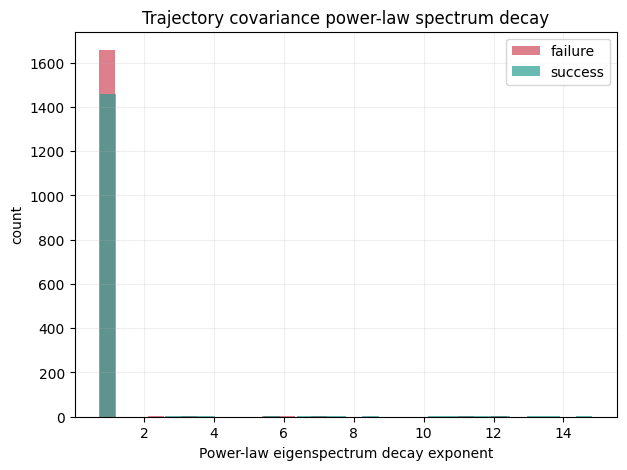

In [5]:
plt.figure(figsize=(7, 5))
if failure_decay:
    plt.hist(failure_decay, bins=30, alpha=0.7, label='failure', color='#d1495b')
if success_decay:
    plt.hist(success_decay, bins=30, alpha=0.7, label='success', color='#2a9d8f')
plt.xlabel('Power-law eigenspectrum decay exponent')
plt.ylabel('count')
plt.title('Trajectory covariance power-law spectrum decay')
plt.legend()
plt.grid(alpha=0.2)
plt.show()

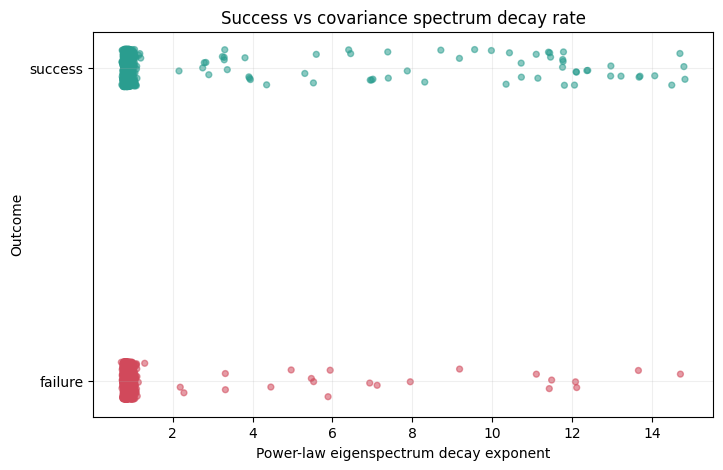

In [6]:
# 2D plot: x = decay rate, y = success indicator with jitter.
x = np.asarray([s['decay_rate'] for s in samples], dtype=np.float64)
y = np.asarray([1.0 if s['success'] else 0.0 for s in samples], dtype=np.float64)
y_jitter = y + np.random.uniform(-0.06, 0.06, size=len(y))

plt.figure(figsize=(8, 5))
colors = np.where(y > 0.5, '#2a9d8f', '#d1495b')
plt.scatter(x, y_jitter, c=colors, s=18, alpha=0.55)
plt.yticks([0, 1], ['failure', 'success'])
plt.xlabel('Power-law eigenspectrum decay exponent')
plt.ylabel('Outcome')
plt.title('Success vs covariance spectrum decay rate')
plt.grid(alpha=0.2)
plt.show()

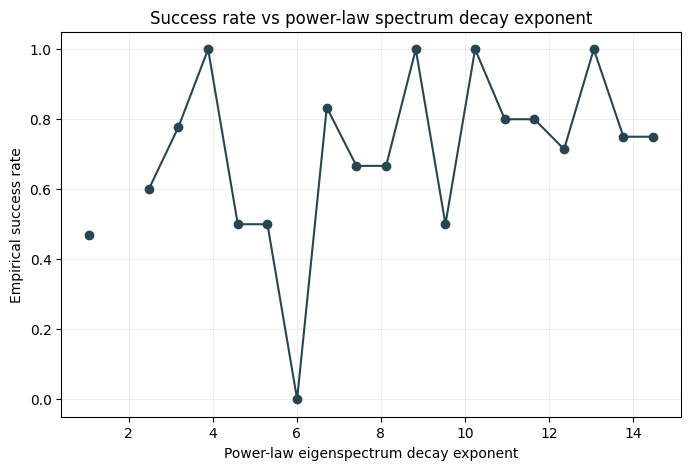

Bin counts: [3118    0    5    9    4    2    6    2    6    3    3    2    2    3
    5   10    7    3    4    4]


In [ ]:
# Bin by decay rate and compute empirical success rate.
def binned_success_rate(samples, n_bins=20, error_mode=TREND_ERROR_MODE):
    x = np.asarray([s['decay_rate'] for s in samples], dtype=np.float64)
    y = np.asarray([1.0 if s['success'] else 0.0 for s in samples], dtype=np.float64)
    edges = np.linspace(x.min(), x.max(), n_bins + 1)
    centers = 0.5 * (edges[:-1] + edges[1:])
    rates = []
    counts = []
    errs = []
    for lo, hi in zip(edges[:-1], edges[1:]):
        mask = (x >= lo) & (x < hi)
        if mask.any():
            vals = y[mask]
            rates.append(float(vals.mean()))
            counts.append(int(mask.sum()))
            std = float(vals.std(ddof=1)) if vals.size > 1 else 0.0
            errs.append(std / math.sqrt(vals.size) if error_mode == 'stderr' else std)
        else:
            rates.append(np.nan)
            counts.append(0)
            errs.append(np.nan)
    return centers, np.asarray(rates), np.asarray(counts), np.asarray(errs)

centers, rates, counts, errs = binned_success_rate(samples, n_bins=20, error_mode=TREND_ERROR_MODE)

plt.figure(figsize=(8, 5))
plt.plot(centers, rates, marker='o', color='#264653')
plt.fill_between(centers, rates - errs, rates + errs, color='#264653', alpha=0.15)
plt.xlabel('Power-law eigenspectrum decay exponent')
plt.ylabel('Empirical success rate')
plt.title('Success rate vs power-law spectrum decay exponent')
plt.ylim(-0.05, 1.05)
plt.grid(alpha=0.2)
plt.show()

print('Bin counts:', counts)

## Success vs Failure Test Statistic

This section compares the decay-exponent distributions for successful and failed trajectories and reports simple effect statistics.


In [8]:
def cliffs_delta(x, y):
    x = np.asarray(x, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)
    if x.size == 0 or y.size == 0:
        return None
    total = 0
    for xv in x:
        total += np.sum(xv > y) - np.sum(xv < y)
    return float(total / (x.size * y.size))


def permutation_mean_diff(x, y, n_perm=2000, seed=1):
    x = np.asarray(x, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)
    observed = float(x.mean() - y.mean())
    pooled = np.concatenate([x, y])
    rng = np.random.default_rng(seed)
    count = 0
    for _ in range(n_perm):
        rng.shuffle(pooled)
        xp = pooled[:x.size]
        yp = pooled[x.size:]
        diff = xp.mean() - yp.mean()
        if abs(diff) >= abs(observed):
            count += 1
    p = (count + 1) / (n_perm + 1)
    return observed, p

success_arr = np.asarray(success_decay, dtype=np.float64)
failure_arr = np.asarray(failure_decay, dtype=np.float64)
print('mean(success) - mean(failure):', float(success_arr.mean() - failure_arr.mean()))
print('cliffs_delta(success, failure):', cliffs_delta(success_arr, failure_arr))
obs, pval = permutation_mean_diff(success_arr, failure_arr, n_perm=2000, seed=RANDOM_SEED)
print('permutation test mean diff:', obs)
print('permutation p-value:', pval)


mean(success) - mean(failure): 0.22165949017993647
cliffs_delta(success, failure): -0.015568477477195072
permutation test mean diff: 0.22165949017993647
permutation p-value: 0.0004997501249375312


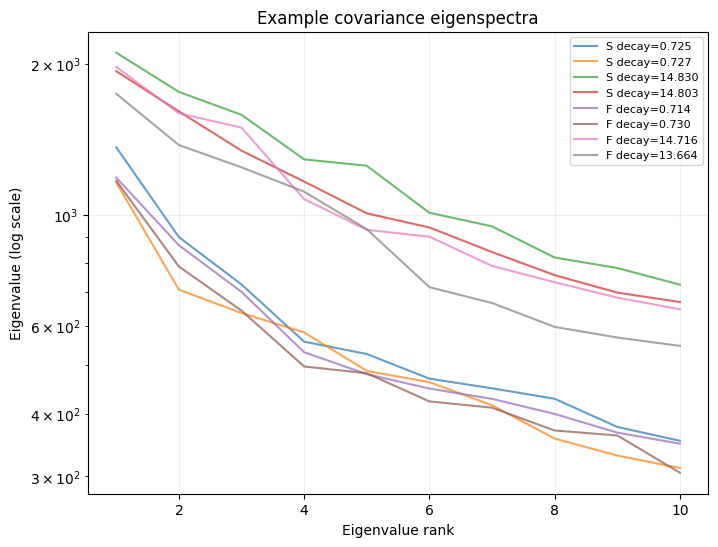

In [9]:
# Show a few example eigenspectra.
interesting = []
interesting.extend(sorted([s for s in samples if s['success']], key=lambda s: s['decay_rate'])[:2])
interesting.extend(sorted([s for s in samples if s['success']], key=lambda s: -s['decay_rate'])[:2])
interesting.extend(sorted([s for s in samples if not s['success']], key=lambda s: s['decay_rate'])[:2])
interesting.extend(sorted([s for s in samples if not s['success']], key=lambda s: -s['decay_rate'])[:2])

plt.figure(figsize=(8, 6))
for item in interesting[:8]:
    vals = item['top_eigvals']
    xs = np.arange(1, len(vals) + 1)
    label = f"{'S' if item['success'] else 'F'} decay={item['decay_rate']:.3f}"
    plt.plot(xs, vals, alpha=0.7, label=label)
plt.yscale('log')
plt.xlabel('Eigenvalue rank')
plt.ylabel('Eigenvalue (log scale)')
plt.title('Example covariance eigenspectra')
plt.grid(alpha=0.2)
plt.legend(fontsize=8)
plt.show()

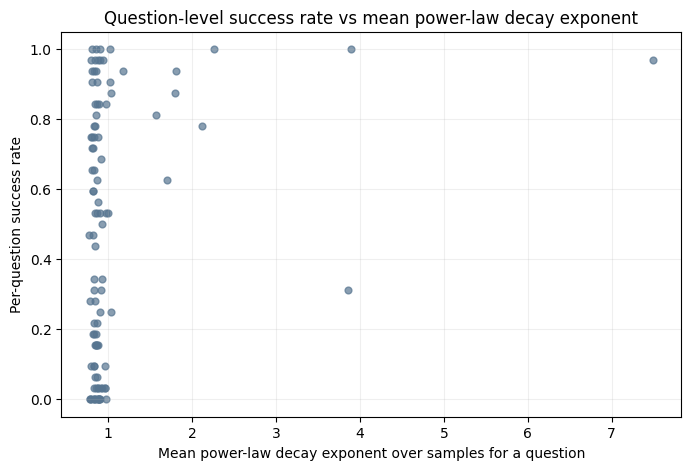

In [ ]:
# Optional: aggregate by question_uid and compare question-level success rate to average decay rate.
by_question = {}
for item in samples:
    by_question.setdefault(item['question_uid'], []).append(item)

question_rows = []
for qid, group in by_question.items():
    question_rows.append({
        'question_uid': qid,
        'n_samples': len(group),
        'success_rate': float(np.mean([1.0 if x['success'] else 0.0 for x in group])),
        'mean_decay_rate': float(np.mean([x['decay_rate'] for x in group])),
        'std_decay_rate': float(np.std([x['decay_rate'] for x in group])),
    })

qx = np.asarray([r['mean_decay_rate'] for r in question_rows], dtype=np.float64)
qy = np.asarray([r['success_rate'] for r in question_rows], dtype=np.float64)

plt.figure(figsize=(8, 5))
plt.scatter(qx, qy, s=24, alpha=0.7, c='#577590')
plt.xlabel('Mean power-law decay exponent over samples for a question')
plt.ylabel('Per-question success rate')
plt.title('Question-level success rate vs mean power-law decay exponent')
plt.grid(alpha=0.2)
plt.show()

## Grouped By Question

This section uses the multi-sample setup to summarize decay exponents per `question_uid`, then relates within-question success rate to the question-level mean and spread of the decay exponent.


Question-level mean decay stats: {'n': 100, 'mean': 1.0578854571011131, 'std': 0.808115982180482, 'min': 0.7760166706114391, 'max': 7.494302747718695}
Question-level std decay stats: {'n': 100, 'mean': 0.3834225903098701, 'std': 1.0151583902547814, 'min': 0.01312054251113507, 'max': 5.524372331813875}


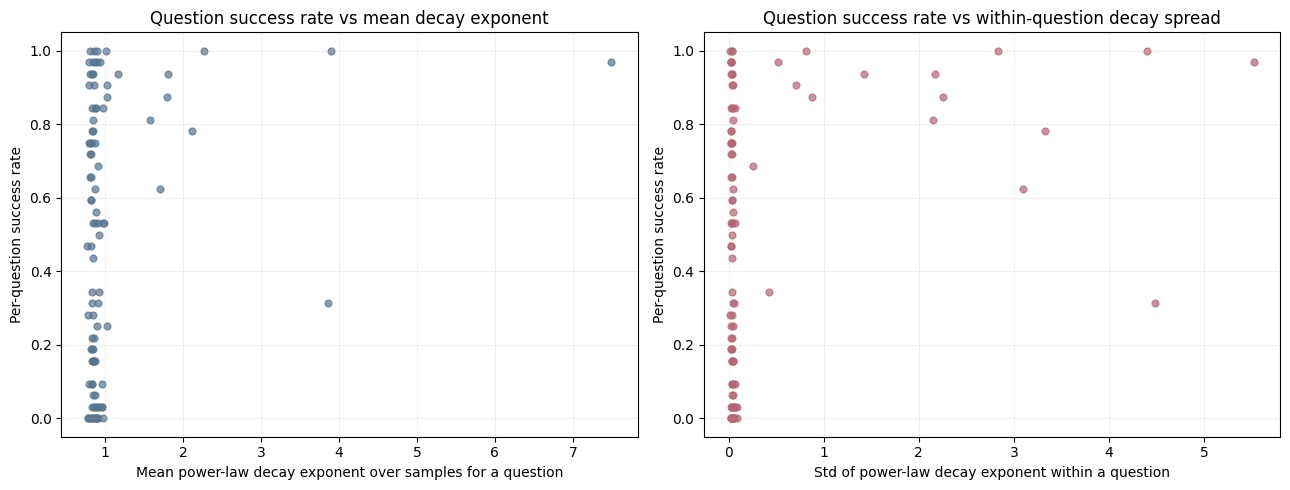

In [11]:
by_question = {}
for item in samples:
    by_question.setdefault(item['question_uid'], []).append(item)

question_rows = []
for qid, group in by_question.items():
    succ = np.asarray([1.0 if x['success'] else 0.0 for x in group], dtype=np.float64)
    dec = np.asarray([x['decay_rate'] for x in group], dtype=np.float64)
    question_rows.append({
        'question_uid': qid,
        'n_samples': len(group),
        'success_rate': float(succ.mean()),
        'mean_decay_rate': float(dec.mean()),
        'std_decay_rate': float(dec.std()),
        'success_mean_decay': float(dec[succ > 0.5].mean()) if np.any(succ > 0.5) else np.nan,
        'failure_mean_decay': float(dec[succ < 0.5].mean()) if np.any(succ < 0.5) else np.nan,
    })

print('Question-level mean decay stats:', summarize([r['mean_decay_rate'] for r in question_rows]))
print('Question-level std decay stats:', summarize([r['std_decay_rate'] for r in question_rows]))

qx = np.asarray([r['mean_decay_rate'] for r in question_rows], dtype=np.float64)
qy = np.asarray([r['success_rate'] for r in question_rows], dtype=np.float64)
qstd = np.asarray([r['std_decay_rate'] for r in question_rows], dtype=np.float64)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(qx, qy, s=24, alpha=0.7, c='#577590')
axes[0].set_xlabel('Mean power-law decay exponent over samples for a question')
axes[0].set_ylabel('Per-question success rate')
axes[0].set_title('Question success rate vs mean decay exponent')
axes[0].grid(alpha=0.2)

axes[1].scatter(qstd, qy, s=24, alpha=0.7, c='#b56576')
axes[1].set_xlabel('Std of power-law decay exponent within a question')
axes[1].set_ylabel('Per-question success rate')
axes[1].set_title('Question success rate vs within-question decay spread')
axes[1].grid(alpha=0.2)
plt.tight_layout()
plt.show()
